## 1. Import Libraries

In [1]:
%pip install xgboost lightgbm catboost

Note: you may need to restart the kernel to use updated packages.


In [75]:
# Basic libraries
import numpy as np
import pandas as pd
import math

# Visualization / EDA
import matplotlib.pyplot as plt
import seaborn as sns

# Train-test split
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

# Preprocessing
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.utils.class_weight import compute_sample_weight

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Boosting models
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Tuning
from sklearn.model_selection import RandomizedSearchCV

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Model Saving
import joblib

# Handling warnings
import warnings
warnings.filterwarnings("ignore")

In [3]:
pd.set_option('display.max_columns', None)

## 2. Dataset Loading and Overview

In [4]:
df = pd.read_csv("IrrigationNeedDataset/train.csv")

In [5]:
# View first few rows
display(df.head())

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,3.85,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,2.31,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,13.94,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [6]:
# Check column names and data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Soil_Type                630000 non-null  str    
 2   Soil_pH                  630000 non-null  float64
 3   Soil_Moisture            630000 non-null  float64
 4   Organic_Carbon           630000 non-null  float64
 5   Electrical_Conductivity  630000 non-null  float64
 6   Temperature_C            630000 non-null  float64
 7   Humidity                 630000 non-null  float64
 8   Rainfall_mm              630000 non-null  float64
 9   Sunlight_Hours           630000 non-null  float64
 10  Wind_Speed_kmh           630000 non-null  float64
 11  Crop_Type                630000 non-null  str    
 12  Crop_Growth_Stage        630000 non-null  str    
 13  Season                   630000 non-null  str    
 14  Irrigation_Type

## 3. Data Cleaning

In [7]:
# Check missing values
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

Series([], dtype: int64)


In [8]:
# Check duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [9]:
# Check basic statistics for numerical columns
display(df.describe())

,id,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,6.482497,37.304482,0.922858,1.744605,26.998166,61.563180,1462.207566,7.513382,10.375394,7.517745,62.318177
std,181865.479132,0.922504,16.377082,0.365808,0.952321,8.623621,19.708152,612.989738,1.999322,5.689458,4.218124,34.246939
min,0.000000,4.800000,8.000000,0.300000,0.100000,12.000000,25.000000,0.380000,4.000000,0.500000,0.300000,0.020000
25%,157499.750000,5.690000,23.340000,0.610000,0.930000,19.517500,45.390000,954.570000,5.760000,5.280000,3.880000,33.140000
50%,314999.500000,6.440000,37.750000,0.910000,1.740000,26.960000,61.650000,1467.160000,7.580000,10.480000,7.380000,61.150000
75%,472499.250000,7.270000,51.270000,1.220000,2.580000,34.540000,79.120000,2054.280000,9.250000,15.430000,11.140000,92.690000
max,629999.000000,8.200000,64.990000,1.600000,3.500000,42.000000,94.990000,2499.690000,11.000000,20.000000,15.000000,119.990000


In [10]:
# Check categorical column summaries
display(df.describe(include="object"))

,Soil_Type,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Mulching_Used,Region,Irrigation_Need
count,630000,630000,630000,630000,630000,630000,630000,630000,630000
unique,4,6,4,3,4,4,2,5,3
top,Sandy,Sugarcane,Harvest,Kharif,Canal,Reservoir,No,South,Low
freq,166509,108910,167689,216561,161901,162994,316453,134809,369917


In [11]:
# Separate numerical and categorical columns
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

print("Numerical columns: ", list(num_cols), "\n")
print("Categorical columns: ", list(cat_cols))

Numerical columns:  ['id', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Field_Area_hectare', 'Previous_Irrigation_mm'] 

Categorical columns:  ['Soil_Type', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Mulching_Used', 'Region', 'Irrigation_Need']


## 4. EDA

In [12]:
data = df.copy()

target_col = "Irrigation_Need"
num_cols = ["Soil_pH", "Soil_Moisture", "Organic_Carbon", "Electrical_Conductivity", "Temperature_C", "Humidity", "Rainfall_mm", "Sunlight_Hours", "Wind_Speed_kmh", "Field_Area_hectare", "Previous_Irrigation_mm"]
cat_cols = ["Soil_Type", "Crop_Type", "Crop_Growth_Stage", "Season", "Irrigation_Type", "Water_Source", "Mulching_Used", "Region"]

### 4.1 Target variable distribution

In [13]:
# Target variable distribution
target_counts = data[target_col].value_counts()
target_percent = data[target_col].value_counts(normalize=True) * 100

target_distribution = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percent.round(2)
})

target_distribution

,Count,Percentage
Irrigation_Need,,
Low,369917,58.72
Medium,239074,37.95
High,21009,3.33


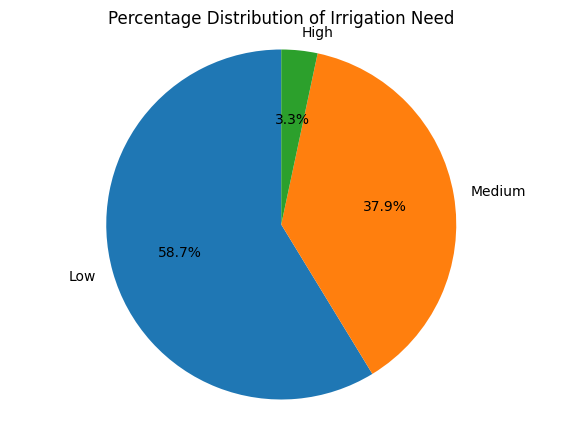

In [14]:
plt.figure(figsize=(7, 5))

plt.pie(
    target_percent,
    labels=target_percent.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Percentage Distribution of Irrigation Need")
plt.axis('equal')  # Makes the pie chart circular
plt.show()

The target variable is imbalanced. Low irrigation need forms the majority class, followed by Medium, while High irrigation need is significantly underrepresented. Therefore, macro F1-score, recall, and confusion matrix should be prioritized during model evaluation.

### 4.2 Numerical Features Distribution

In [15]:
data[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Soil_pH,630000.0,6.482497,0.922504,4.80,5.6900,6.44,7.27,8.20
Soil_Moisture,630000.0,37.304482,16.377082,8.00,23.3400,37.75,51.27,64.99
Organic_Carbon,630000.0,0.922858,0.365808,0.30,0.6100,0.91,1.22,1.60
Electrical_Conductivity,630000.0,1.744605,0.952321,0.10,0.9300,1.74,2.58,3.50
Temperature_C,630000.0,26.998166,8.623621,12.00,19.5175,26.96,34.54,42.00
Humidity,630000.0,61.563180,19.708152,25.00,45.3900,61.65,79.12,94.99
Rainfall_mm,630000.0,1462.207566,612.989738,0.38,954.5700,1467.16,2054.28,2499.69
Sunlight_Hours,630000.0,7.513382,1.999322,4.00,5.7600,7.58,9.25,11.00
Wind_Speed_kmh,630000.0,10.375394,5.689458,0.50,5.2800,10.48,15.43,20.00
Field_Area_hectare,630000.0,7.517745,4.218124,0.30,3.8800,7.38,11.14,15.00


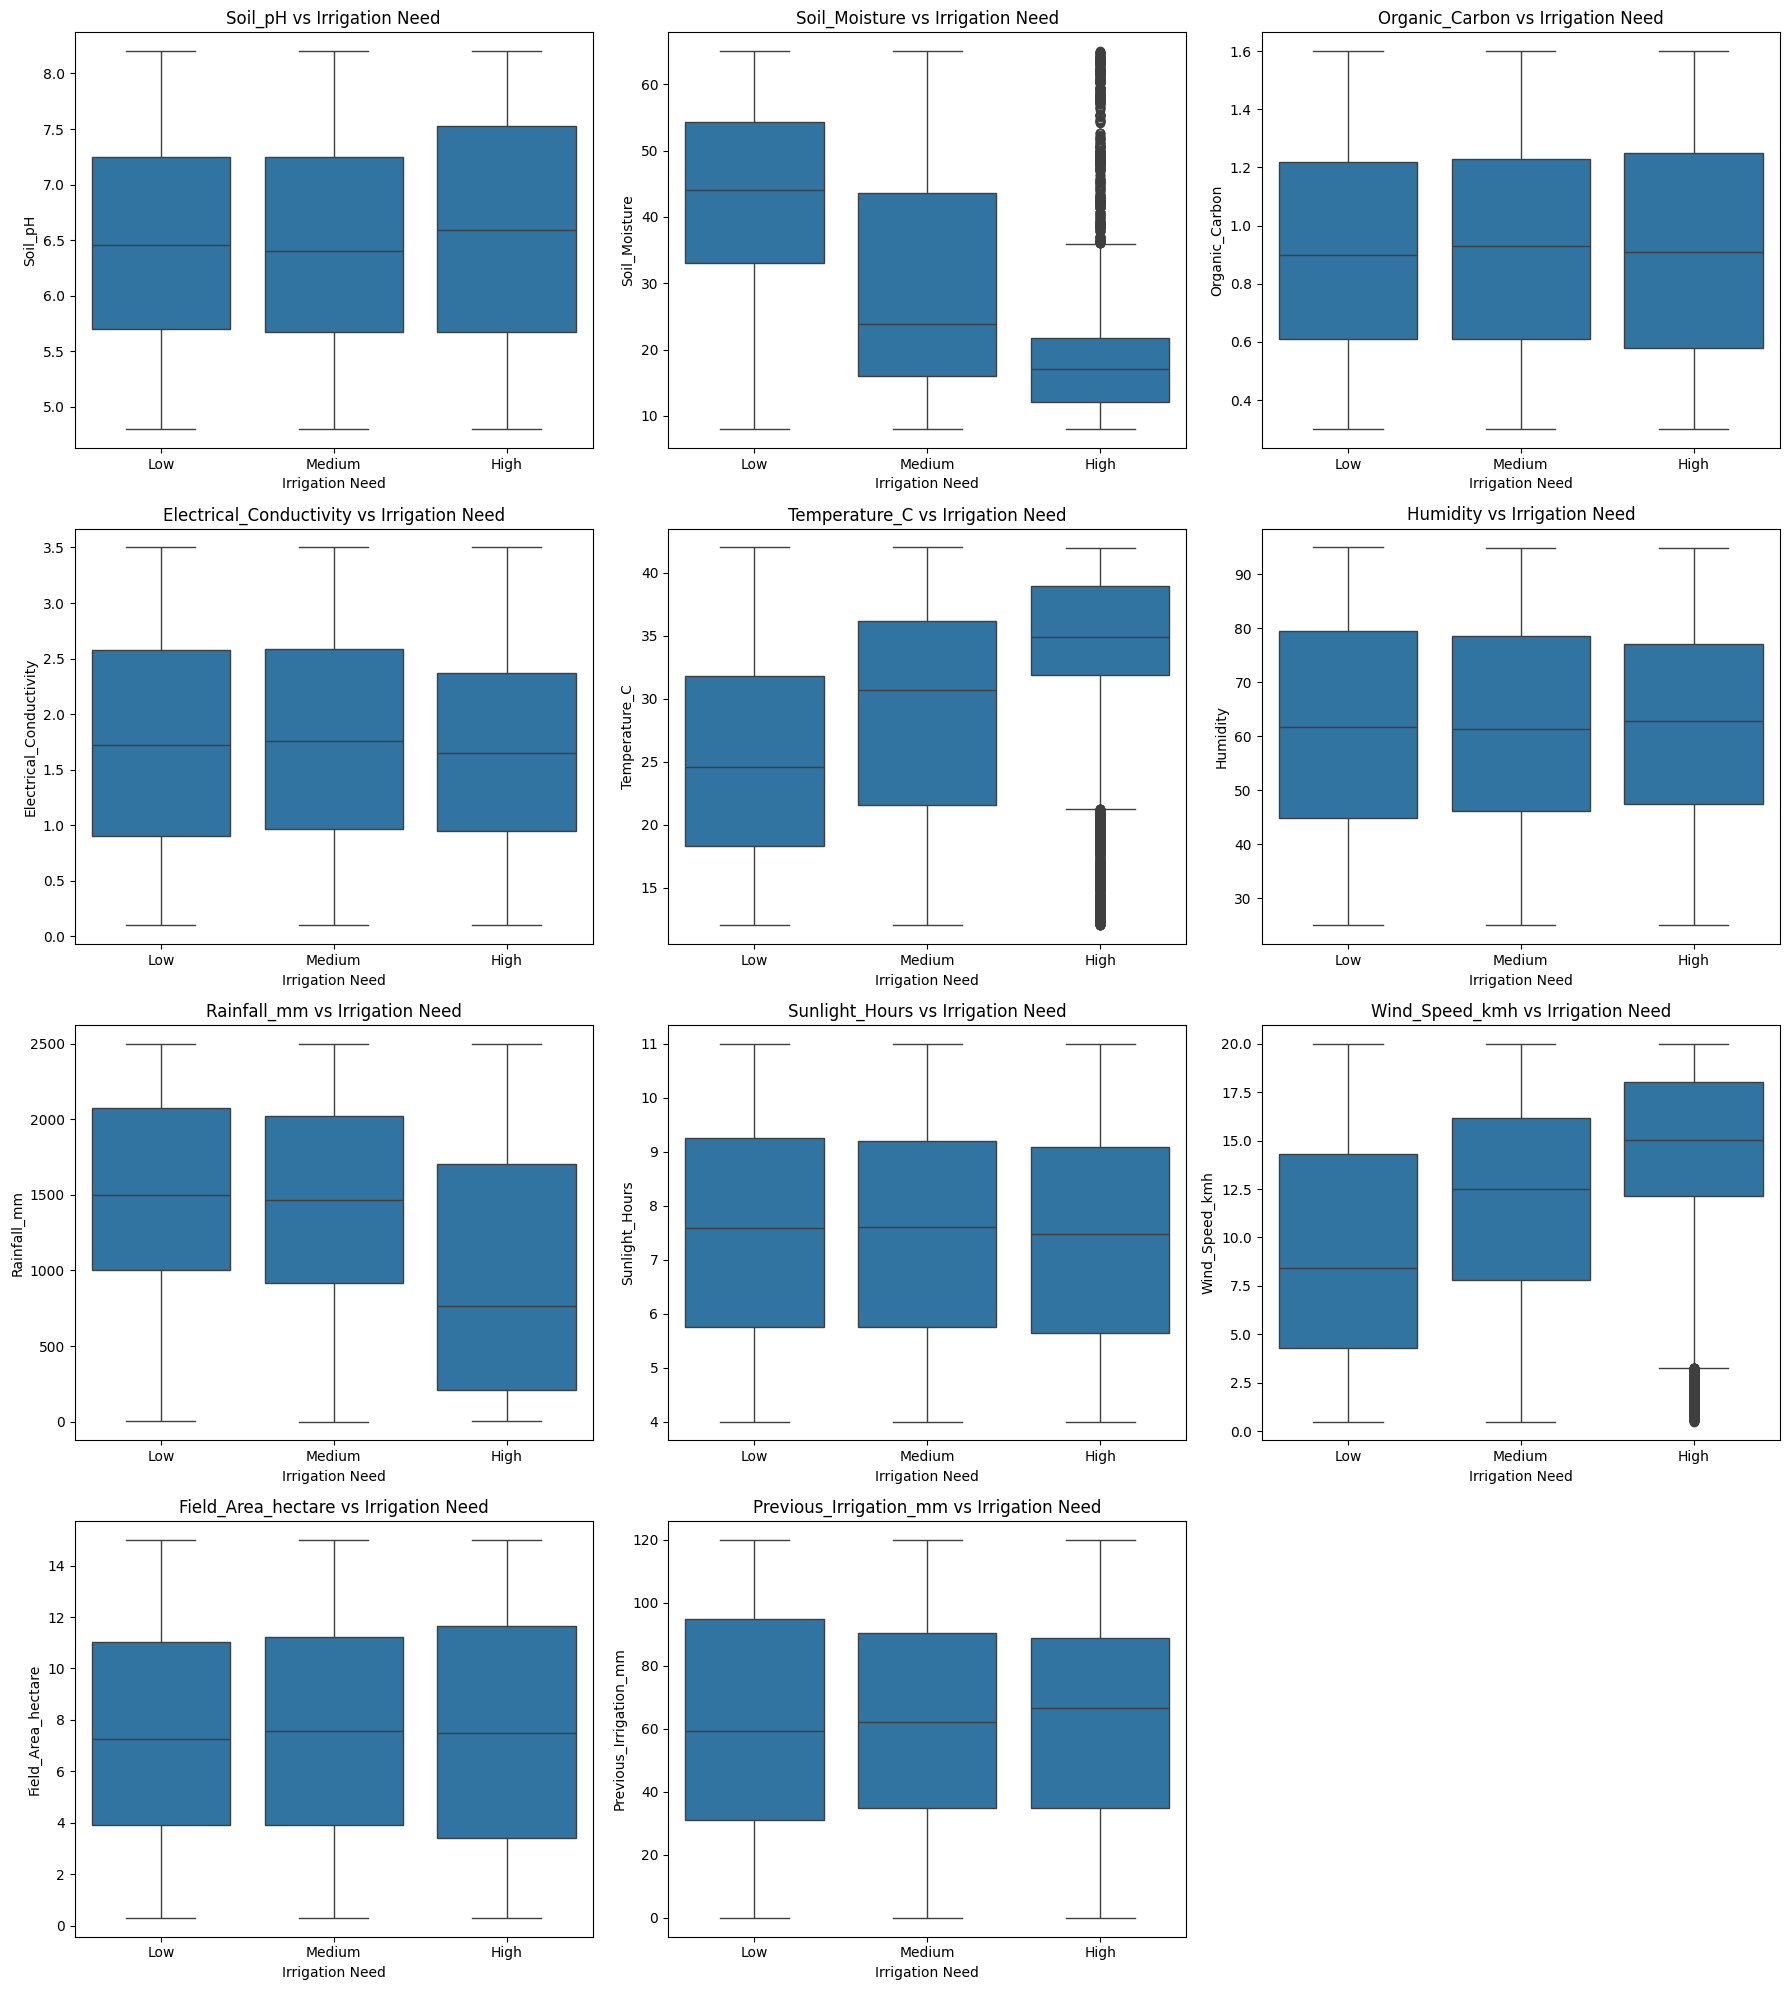

In [16]:
target_order = ["Low", "Medium", "High"]

# 3 plots per row
n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))

# Flatten axes for easy looping
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(
        data=data,
        x=target_col,
        y=col,
        order=target_order,
        ax=axes[i]
    )
    
    axes[i].set_title(f"{col} vs Irrigation Need")
    axes[i].set_xlabel("Irrigation Need")
    axes[i].set_ylabel(col)

# Remove unused empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

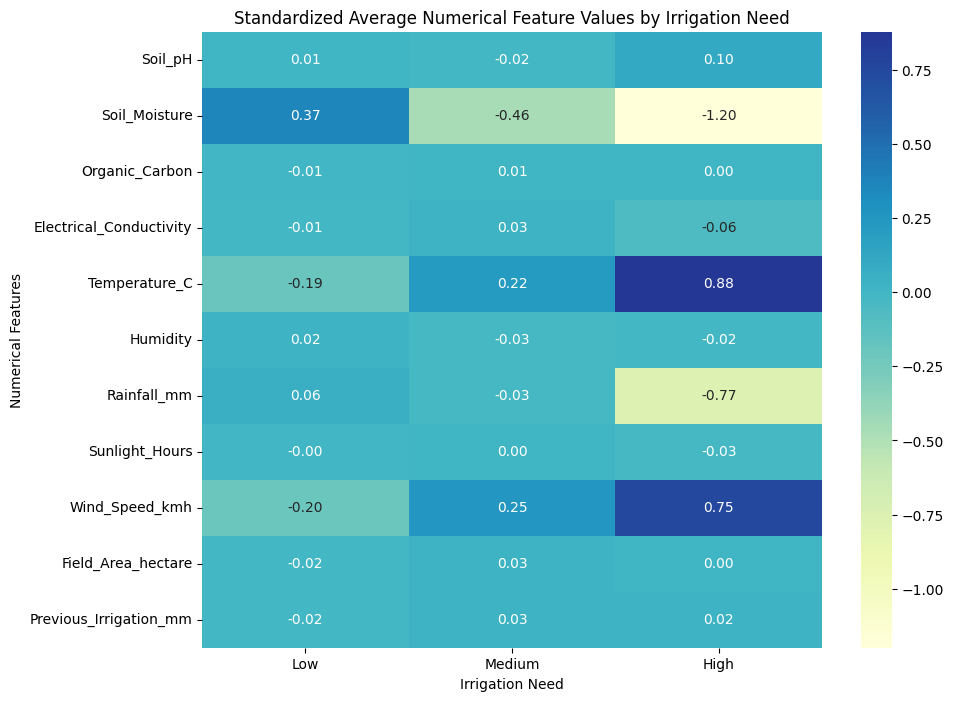

In [17]:
# Scale numerical columns
scaler = StandardScaler()

scaled_num_data = pd.DataFrame(
    scaler.fit_transform(data[num_cols]),
    columns=num_cols,
    index=data.index
)

# Add target column back
scaled_num_data[target_col] = data[target_col]

# Group by target and calculate mean
scaled_summary_by_target = scaled_num_data.groupby(target_col)[num_cols].mean().T
scaled_summary_by_target = scaled_summary_by_target[["Low", "Medium", "High"]]
# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    scaled_summary_by_target,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    center=0
)

plt.title("Standardized Average Numerical Feature Values by Irrigation Need")
plt.xlabel("Irrigation Need")
plt.ylabel("Numerical Features")
plt.show()

Since numerical features were measured on different scales, raw mean values were standardized before visualization. This allowed a fair comparison of feature patterns across irrigation need classes without large-scale variables dominating the heatmap.

### 4.3 Categorical Feature Distribution

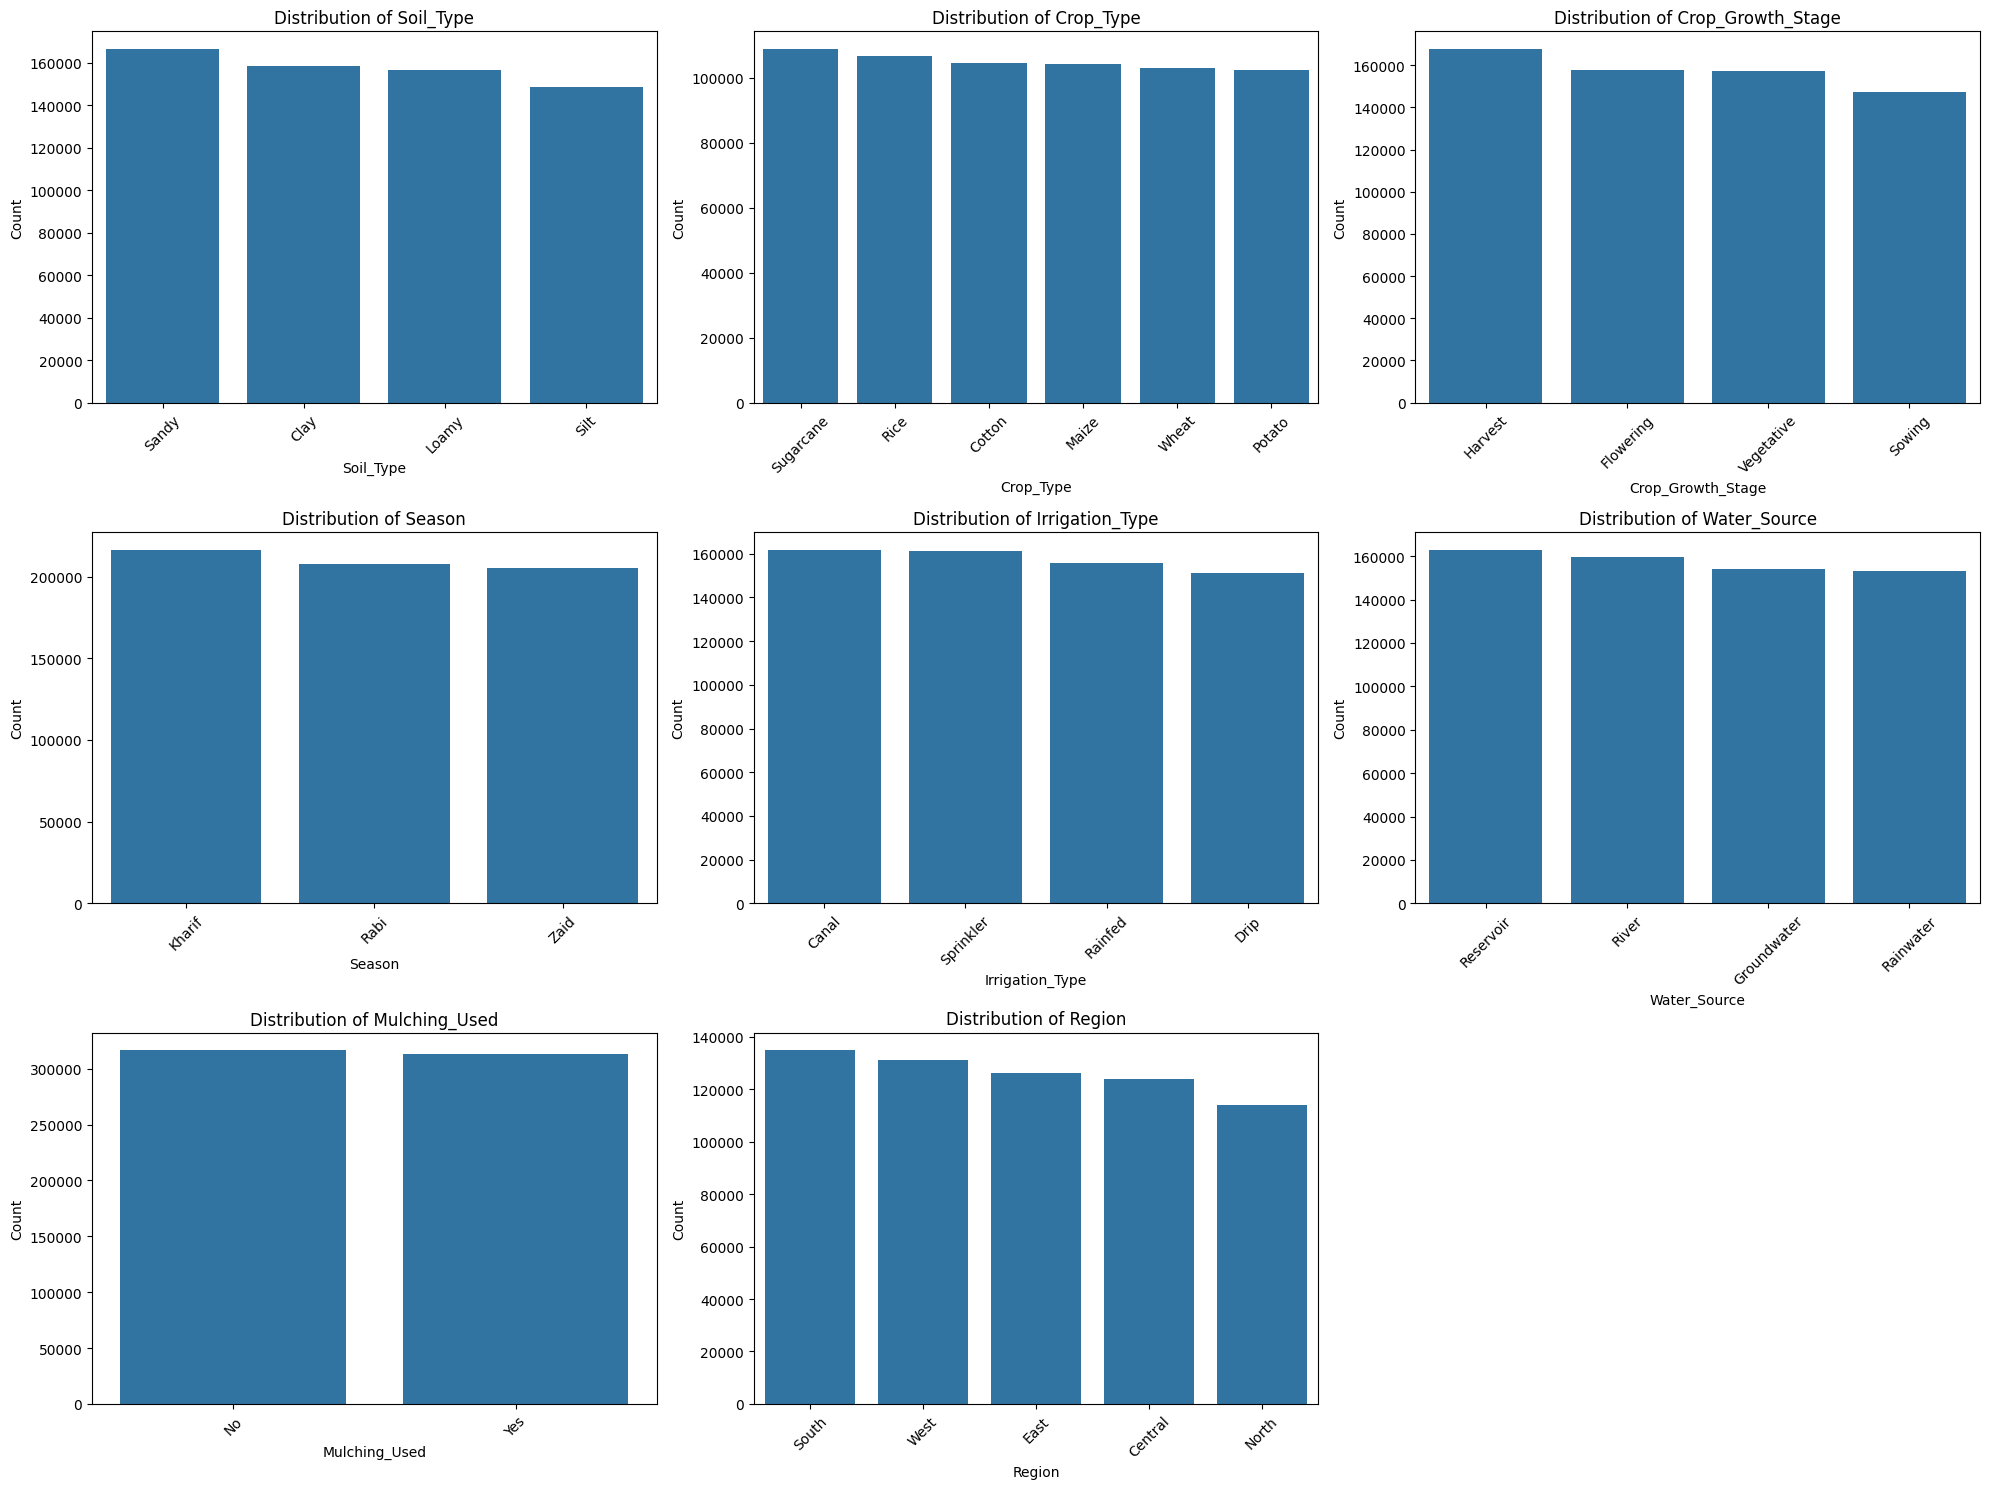

In [18]:
n_cols = 3
n_rows = math.ceil(len(cat_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(
        data=data,
        x=col,
        order=data[col].value_counts().index,
        ax=axes[i]
    )
    
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis="x", rotation=45)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

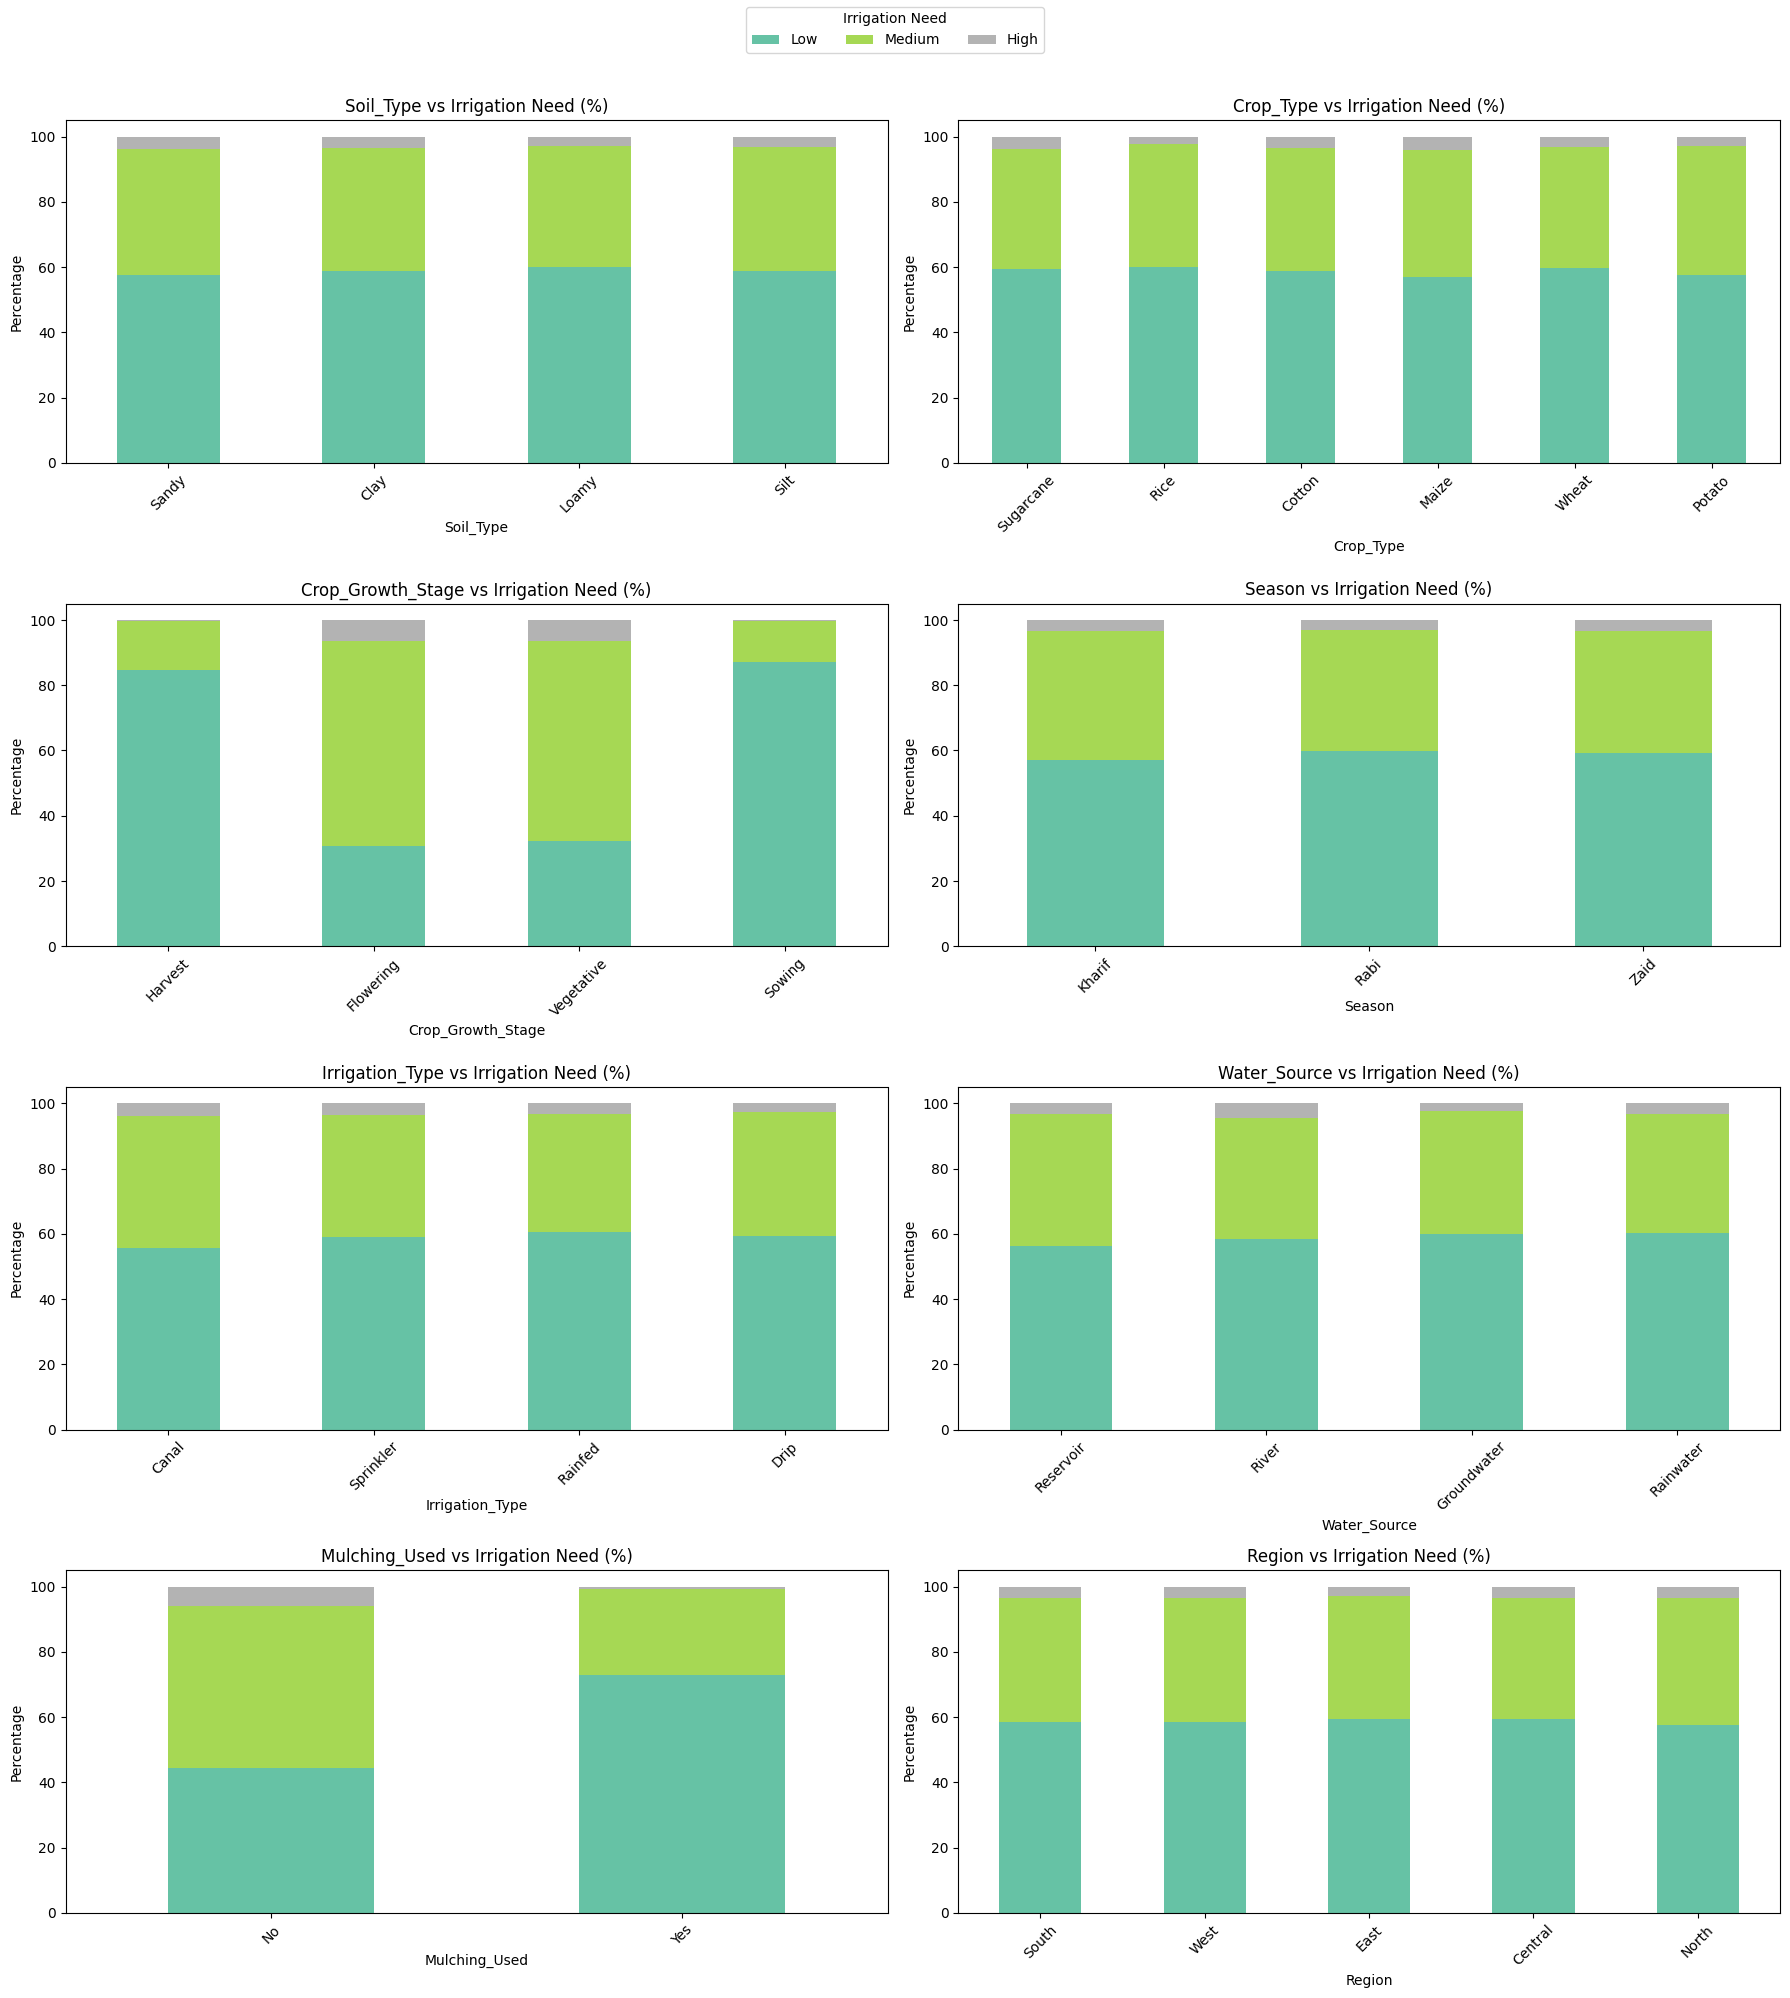

In [19]:
target_order = ["Low", "Medium", "High"]

n_cols = 2
n_rows = math.ceil(len(cat_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    
    cross_tab = pd.crosstab(
        data[col],
        data[target_col],
        normalize="index"
    ) * 100
    
    cross_tab = cross_tab.reindex(columns=target_order)
    
    category_order = data[col].value_counts().index
    cross_tab = cross_tab.loc[category_order]
    
    cross_tab.plot(
        kind="bar",
        stacked=True,
        ax=axes[i],
        colormap="Set2",
        legend=False
    )
    
    axes[i].set_title(f"{col} vs Irrigation Need (%)")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Percentage")
    axes[i].tick_params(axis="x", rotation=45)

# Remove unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Common legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="Irrigation Need",
    loc="upper center",
    ncol=3
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### 4.4 Correlation Analysis for Numerical Features

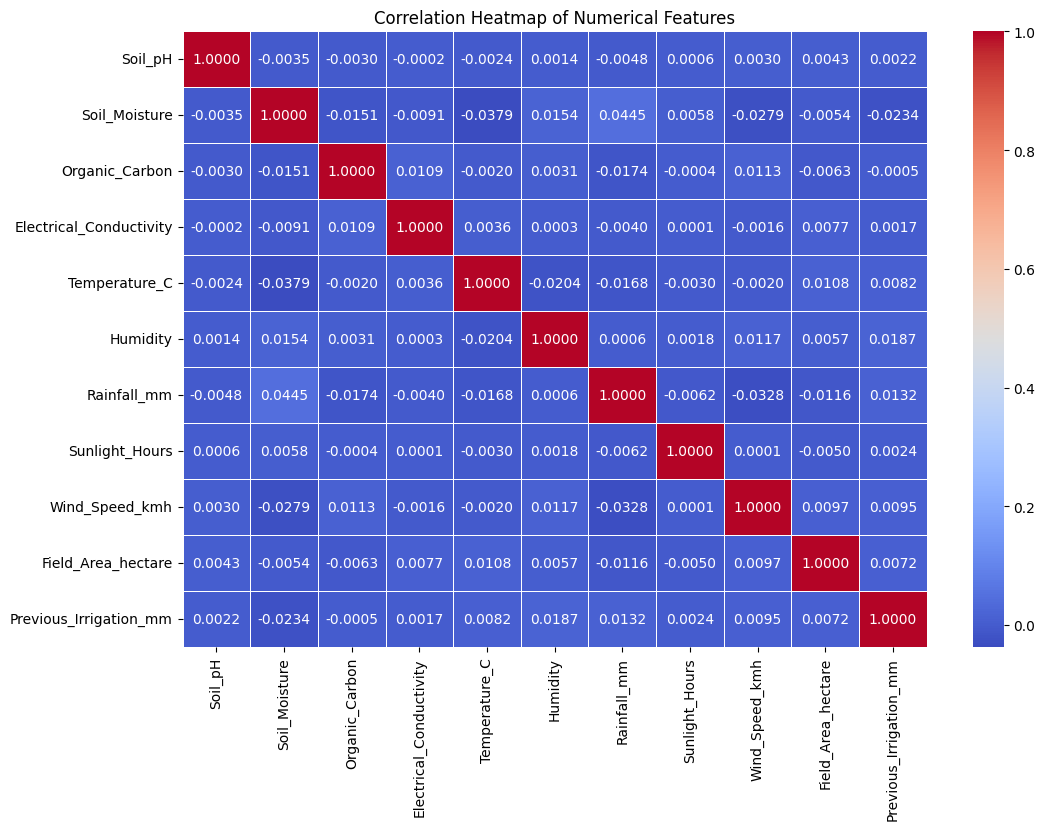

In [20]:
corr_matrix = data[num_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".4f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

All numerical features are relatively evenly distributed and with very low correlation

### 4.5 Outlier Detection

In [21]:
outlier_summary = []

for col in num_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
    
    outlier_summary.append({
        "Feature": col,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Outlier_Count": outliers.shape[0],
        "Outlier_Percentage": round((outliers.shape[0] / data.shape[0]) * 100, 2)
    })

outlier_summary_df = pd.DataFrame(outlier_summary)
outlier_summary_df

,Feature,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
0,Soil_pH,3.32000,9.64000,0,0.0
1,Soil_Moisture,-18.55500,93.16500,0,0.0
2,Organic_Carbon,-0.30500,2.13500,0,0.0
3,Electrical_Conductivity,-1.54500,5.05500,0,0.0
4,Temperature_C,-3.01625,57.07375,0,0.0
5,Humidity,-5.20500,129.71500,0,0.0
6,Rainfall_mm,-694.99500,3703.84500,0,0.0
7,Sunlight_Hours,0.52500,14.48500,0,0.0
8,Wind_Speed_kmh,-9.94500,30.65500,0,0.0
9,Field_Area_hectare,-7.01000,22.03000,0,0.0


### 4.6 Skewness Analysis

In [22]:
skewness = data[num_cols].skew().sort_values(ascending=False)

skewness_df = pd.DataFrame({
    "Feature": skewness.index,
    "Skewness": skewness.values
})

skewness_df

,Feature,Skewness
0,Organic_Carbon,0.105044
1,Soil_pH,0.069547
2,Field_Area_hectare,0.052216
3,Electrical_Conductivity,0.048054
4,Temperature_C,-0.003627
5,Previous_Irrigation_mm,-0.017108
6,Wind_Speed_kmh,-0.027756
7,Sunlight_Hours,-0.034897
8,Soil_Moisture,-0.063614
9,Humidity,-0.088835


### 4.7 Other important relations between features

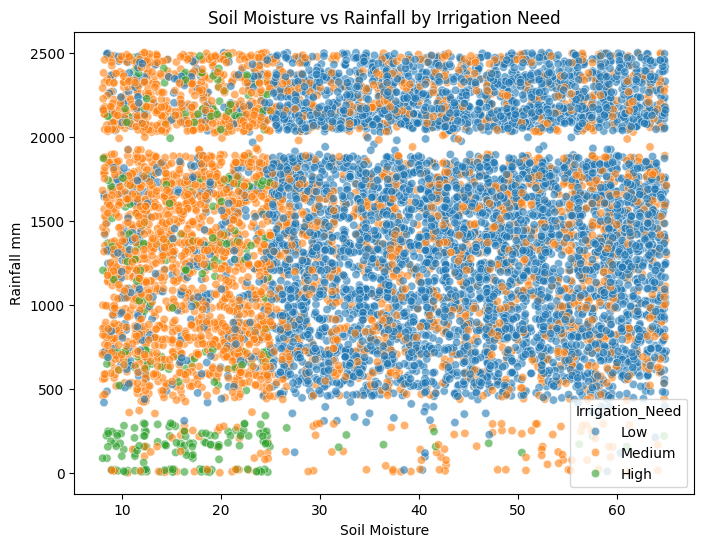

In [23]:
sample_data = data.sample(n=10000, random_state=42)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=sample_data,
    x="Soil_Moisture",
    y="Rainfall_mm",
    hue=target_col,
    alpha=0.6
)
plt.title("Soil Moisture vs Rainfall by Irrigation Need")
plt.xlabel("Soil Moisture")
plt.ylabel("Rainfall mm")
plt.show()

In [24]:
crop_irrigation = pd.crosstab(
    data["Crop_Type"],
    data[target_col],
    normalize="index"
) * 100

crop_irrigation = crop_irrigation[["Low", "Medium", "High"]]
crop_irrigation.round(2)

Irrigation_Need,Low,Medium,High
Crop_Type,,,
Cotton,58.72,37.67,3.61
Maize,57.01,38.77,4.22
Potato,57.59,39.67,2.74
Rice,59.99,37.68,2.34
Sugarcane,59.29,36.80,3.92
Wheat,59.65,37.18,3.17


In [25]:
growth_irrigation = pd.crosstab(
    data["Crop_Growth_Stage"],
    data[target_col],
    normalize="index"
) * 100

growth_irrigation = growth_irrigation[["Low", "Medium", "High"]]
growth_irrigation.round(2)

Irrigation_Need,Low,Medium,High
Crop_Growth_Stage,,,
Flowering,30.60,62.96,6.44
Harvest,84.79,14.89,0.32
Sowing,87.18,12.65,0.16
Vegetative,32.38,61.21,6.41


In [26]:
eda_summary = pd.DataFrame({
    "Feature": num_cols,
    "Mean": data[num_cols].mean().values,
    "Median": data[num_cols].median().values,
    "Std": data[num_cols].std().values,
    "Min": data[num_cols].min().values,
    "Max": data[num_cols].max().values,
    "Skewness": data[num_cols].skew().values
})

eda_summary.round(2)

,Feature,Mean,Median,Std,Min,Max,Skewness
0,Soil_pH,6.48,6.44,0.92,4.80,8.20,0.07
1,Soil_Moisture,37.30,37.75,16.38,8.00,64.99,-0.06
2,Organic_Carbon,0.92,0.91,0.37,0.30,1.60,0.11
3,Electrical_Conductivity,1.74,1.74,0.95,0.10,3.50,0.05
4,Temperature_C,27.00,26.96,8.62,12.00,42.00,-0.00
5,Humidity,61.56,61.65,19.71,25.00,94.99,-0.09
6,Rainfall_mm,1462.21,1467.16,612.99,0.38,2499.69,-0.12
7,Sunlight_Hours,7.51,7.58,2.00,4.00,11.00,-0.03
8,Wind_Speed_kmh,10.38,10.48,5.69,0.50,20.00,-0.03
9,Field_Area_hectare,7.52,7.38,4.22,0.30,15.00,0.05


EDA showed that the target variable is highly imbalanced, with the High irrigation need class being significantly underrepresented. Numerical features such as soil moisture, rainfall, temperature, humidity, sunlight hours, and previous irrigation are important for understanding irrigation requirements. Categorical variables such as crop type, growth stage, season, irrigation type, water source, and region help capture farm and environmental conditions. Correlation and distribution analysis were used to identify relationships among numerical variables, while stacked bar charts helped compare irrigation need patterns across categorical groups.

## 5. Feature Engineering

In [79]:
%%writefile feature_engineering.py

import numpy as np
import pandas as pd

def add_irrigation_features(df):
    df = df.copy()
    eps = 1e-6

    # -------------------------------------------------
    # 1. Basic water availability features
    # -------------------------------------------------

    df["total_water_input"] = (
        df["Rainfall_mm"] + df["Previous_Irrigation_mm"]
    )

    df["rainfall_minus_prev_irr"] = (
        df["Rainfall_mm"] - df["Previous_Irrigation_mm"]
    )

    df["prev_irr_minus_rainfall"] = (
        df["Previous_Irrigation_mm"] - df["Rainfall_mm"]
    )

    df["water_input_per_hectare"] = (
        df["total_water_input"] / (df["Field_Area_hectare"] + eps)
    )

    df["rainfall_per_hectare"] = (
        df["Rainfall_mm"] / (df["Field_Area_hectare"] + eps)
    )

    df["prev_irr_per_hectare"] = (
        df["Previous_Irrigation_mm"] / (df["Field_Area_hectare"] + eps)
    )

    # -------------------------------------------------
    # 2. Moisture and deficit features
    # -------------------------------------------------

    df["moisture_deficit"] = 100 - df["Soil_Moisture"]

    df["moisture_humidity_ratio"] = (
        df["Soil_Moisture"] / (df["Humidity"] + eps)
    )

    df["rainfall_moisture_ratio"] = (
        df["Rainfall_mm"] / (df["Soil_Moisture"] + eps)
    )

    df["prev_irr_moisture_ratio"] = (
        df["Previous_Irrigation_mm"] / (df["Soil_Moisture"] + eps)
    )

    df["water_input_moisture_ratio"] = (
        df["total_water_input"] / (df["Soil_Moisture"] + eps)
    )

    df["field_moisture_reserve"] = (
        df["Field_Area_hectare"] * df["Soil_Moisture"]
    )

    # -------------------------------------------------
    # 3. Evaporation / water loss proxy features
    # -------------------------------------------------

    df["temp_humidity_index"] = (
        df["Temperature_C"] * df["Humidity"] / 100
    )

    df["temperature_sunlight"] = (
        df["Temperature_C"] * df["Sunlight_Hours"]
    )

    df["sunlight_wind"] = (
        df["Sunlight_Hours"] * df["Wind_Speed_kmh"]
    )

    df["wind_humidity_interaction"] = (
        df["Wind_Speed_kmh"] * df["Humidity"]
    )

    df["evapotranspiration_proxy"] = (
        df["Temperature_C"] 
        * df["Sunlight_Hours"] 
        * (1 + df["Wind_Speed_kmh"] / 20)
        / (df["Humidity"] + eps)
    )

    df["evaporation_pressure"] = (
        df["Temperature_C"] * 0.45
        + df["Sunlight_Hours"] * 0.35
        + df["Wind_Speed_kmh"] * 0.20
    )

    df["dryness_index"] = (
        df["evapotranspiration_proxy"] / (df["total_water_input"] + eps)
    )

    # -------------------------------------------------
    # 4. Rainfall and sunlight relationship
    # -------------------------------------------------

    df["rain_per_sunshine"] = (
        df["Rainfall_mm"] / (df["Sunlight_Hours"] + eps)
    )

    df["temp_rainfall_ratio"] = (
        df["Temperature_C"] / (df["Rainfall_mm"] + eps)
    )

    df["sunlight_rainfall_ratio"] = (
        df["Sunlight_Hours"] / (df["Rainfall_mm"] + eps)
    )

    df["rainfall_humidity_interaction"] = (
        df["Rainfall_mm"] * df["Humidity"]
    )

    # -------------------------------------------------
    # 5. Soil health / salinity interaction features
    # -------------------------------------------------

    df["ec_ph_interaction"] = (
        df["Electrical_Conductivity"] * df["Soil_pH"]
    )

    df["carbon_moisture"] = (
        df["Organic_Carbon"] * df["Soil_Moisture"]
    )

    df["carbon_ph_interaction"] = (
        df["Organic_Carbon"] * df["Soil_pH"]
    )

    df["salinity_moisture_stress"] = (
        df["Electrical_Conductivity"] / (df["Soil_Moisture"] + eps)
    )

    df["soil_health_index"] = (
        df["Organic_Carbon"] * df["Soil_Moisture"]
        / (df["Electrical_Conductivity"] + eps)
    )

    df["ph_deviation_from_neutral"] = (
        abs(df["Soil_pH"] - 7)
    )

    # -------------------------------------------------
    # 6. Net irrigation need proxy
    # -------------------------------------------------

    df["net_water_need"] = (
        df["moisture_deficit"]
        + df["evapotranspiration_proxy"]
        - df["total_water_input"] / 100
    )

    df["water_balance_index"] = (
        df["total_water_input"]
        - df["evapotranspiration_proxy"]
        - df["moisture_deficit"]
    )

    df["water_stress_index"] = (
        df["moisture_deficit"]
        * df["evapotranspiration_proxy"]
        / (df["total_water_input"] + eps)
    )

    # -------------------------------------------------
    # 7. Field scale interaction features
    # -------------------------------------------------

    df["field_rainfall"] = (
        df["Field_Area_hectare"] * df["Rainfall_mm"]
    )

    df["field_previous_irrigation"] = (
        df["Field_Area_hectare"] * df["Previous_Irrigation_mm"]
    )

    df["field_water_input"] = (
        df["Field_Area_hectare"] * df["total_water_input"]
    )

    df["field_evaporation_pressure"] = (
        df["Field_Area_hectare"] * df["evaporation_pressure"]
    )

    df = df.replace([np.inf, -np.inf], np.nan)

    return df

Writing feature_engineering.py


In [80]:
from feature_engineering import add_irrigation_features

In [28]:
data_fe = add_irrigation_features(data)

print("Before feature engineering:", data.shape)
print("After feature engineering:", data_fe.shape)

data_fe.head()

Before feature engineering: (630000, 21)
After feature engineering: (630000, 57)


,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need,total_water_input,rainfall_minus_prev_irr,prev_irr_minus_rainfall,water_input_per_hectare,rainfall_per_hectare,prev_irr_per_hectare,moisture_deficit,moisture_humidity_ratio,rainfall_moisture_ratio,prev_irr_moisture_ratio,water_input_moisture_ratio,field_moisture_reserve,temp_humidity_index,temperature_sunlight,sunlight_wind,wind_humidity_interaction,evapotranspiration_proxy,evaporation_pressure,dryness_index,rain_per_sunshine,temp_rainfall_ratio,sunlight_rainfall_ratio,rainfall_humidity_interaction,ec_ph_interaction,carbon_moisture,carbon_ph_interaction,salinity_moisture_stress,soil_health_index,ph_deviation_from_neutral,net_water_need,water_balance_index,water_stress_index,field_rainfall,field_previous_irrigation,field_water_input,field_evaporation_pressure
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,16.79,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low,838.15,613.83,-613.83,1022.132900,885.352579,136.780321,67.42,0.643746,22.283302,3.442603,25.725905,26.7156,7.596561,88.5590,99.0610,849.7419,3.218816,12.1775,0.003840,123.049132,0.020675,0.008127,36742.3539,15.0060,32.9058,4.9692,0.093616,10.788783,2.08,62.257316,767.511184,0.258919,595.3118,91.9712,687.2830,9.985550
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,3.39,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low,1032.82,938.50,-938.50,195.980987,187.032223,8.948765,43.39,0.834217,17.411411,0.833068,18.244479,298.3347,15.553512,159.9816,23.6622,230.0454,2.757125,13.4350,0.002670,141.212014,0.023253,0.007082,66886.8876,14.1600,24.9084,3.1152,0.035329,12.454194,0.08,35.818925,986.672875,0.115830,5194.4282,248.5332,5442.9614,70.802450
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,3.85,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low,2312.08,2091.32,-2091.32,280.592199,267.196570,13.395629,72.29,0.300477,79.455068,3.983399,83.438467,228.3304,24.871734,163.1685,23.2925,355.0470,2.109937,15.0240,0.000913,363.917295,0.012250,0.002748,203040.7740,16.1027,22.4451,4.6089,0.102129,7.931128,1.31,51.279137,2237.680063,0.065970,18142.0080,909.5312,19051.5392,123.797760
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,2.31,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium,1411.18,1303.48,-1303.48,169.612960,163.140605,6.472355,86.68,0.216339,101.901644,4.042792,105.944436,110.8224,8.201124,121.4784,21.0672,142.2267,2.200896,9.6480,0.001560,148.830028,0.009813,0.006719,83570.8081,4.9155,17.7156,7.5145,0.065315,20.362735,1.35,74.769096,1322.299104,0.135187,11292.9856,448.0320,11741.0176,80.271360
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,13.94,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low,1631.39,1445.01,-1445.01,221.355465,208.710962,12.644503,40.86,0.649105,26.009469,1.575752,27.585221,435.8618,18.422442,140.5290,96.8830,1270.0734,2.617470,14.3195,0.001604,221.323709,0.013145,0.004518,140145.4020,7.6416,22.4732,3.0248,0.016233,23.409559,0.96,27.163570,1587.912530,0.065557,11336.5340,686.8103,12023.3443,105.534715


In [29]:
# Check missing values
missing_values = data_fe.isnull().sum()
print(missing_values[missing_values > 0])

Series([], dtype: int64)


## 6. Train-Test split

In [30]:
if "id" in data_fe.columns:
    data_fe = data_fe.drop("id", axis=1)

In [31]:
target_col = "Irrigation_Need"

X = data_fe.drop(target_col, axis=1)
y = data_fe[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (630000, 55)
y shape: (630000,)


In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [33]:
print("Training target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training target distribution:
Irrigation_Need
Low       58.717063
Medium    37.948214
High       3.334722
Name: proportion, dtype: float64

Testing target distribution:
Irrigation_Need
Low       58.716667
Medium    37.948413
High       3.334921
Name: proportion, dtype: float64


In [34]:
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numerical columns:", len(num_cols))
print("Categorical columns:", len(cat_cols))

Numerical columns: 47
Categorical columns: 8


## 7. Preprocessing

In [36]:
logreg_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols),

        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols)
    ]
)

In [37]:
tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median"))
        ]), num_cols),

        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols)
    ]
)

In [40]:
# CatBoost data preprocessing
X_train_cb = X_train.copy()
X_test_cb = X_test.copy()

# Fill missing numerical values
for col in num_cols:
    median_value = X_train_cb[col].median()
    X_train_cb[col] = X_train_cb[col].fillna(median_value)
    X_test_cb[col] = X_test_cb[col].fillna(median_value)

# Fill missing categorical values
for col in cat_cols:
    X_train_cb[col] = X_train_cb[col].astype(str).fillna("Unknown")
    X_test_cb[col] = X_test_cb[col].astype(str).fillna("Unknown")

In [38]:
target_encoder = LabelEncoder()

y_train_encoded = target_encoder.fit_transform(y_train)
y_test_encoded = target_encoder.transform(y_test)

print(target_encoder.classes_)

['High' 'Low' 'Medium']


## 8. Model Training

In [41]:
# Logistic Regression pipeline
logreg_pipeline = Pipeline(steps=[
    ("preprocessor", logreg_preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

# Decision Tree pipeline
dt_pipeline = Pipeline(steps=[
    ("preprocessor", tree_preprocessor),
    ("model", DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    ))
])

# Random Forest pipeline
rf_pipeline = Pipeline(steps=[
    ("preprocessor", tree_preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

# XGBoost pipeline
xgb_pipeline = Pipeline(steps=[
    ("preprocessor", tree_preprocessor),
    ("model", XGBClassifier(
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1
    ))
])

# LightGBM pipeline
lgbm_pipeline = Pipeline(steps=[
    ("preprocessor", tree_preprocessor),
    ("model", LGBMClassifier(
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

In [46]:
models = {
    "Logistic Regression": logreg_pipeline,
    "Decision Tree": dt_pipeline,
    "Random Forest": rf_pipeline,
    "XGBoost": xgb_pipeline,
    "LightGBM": lgbm_pipeline
}

In [47]:
def evaluate_model(model_name, y_true, y_pred):
    print("=" * 70)
    print(model_name)
    print("=" * 70)

    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision Macro:", precision_score(y_true, y_pred, average="macro"))
    print("Recall Macro:", recall_score(y_true, y_pred, average="macro"))
    print("F1 Macro:", f1_score(y_true, y_pred, average="macro"))
    print("F1 Weighted:", f1_score(y_true, y_pred, average="weighted"))

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

In [48]:
results = []

for name, model in models.items():

    print(f"\nTraining {name}...")

    if name == "XGBoost":
        model.fit(X_train, y_train_encoded)
        y_pred_encoded = model.predict(X_test)
        y_pred = target_encoder.inverse_transform(y_pred_encoded.astype(int))
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    precision_macro = precision_score(y_test, y_pred, average="macro")
    recall_macro = recall_score(y_test, y_pred, average="macro")
    f1_macro = f1_score(y_test, y_pred, average="macro")
    f1_weighted = f1_score(y_test, y_pred, average="weighted")

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision_Macro": precision_macro,
        "Recall_Macro": recall_macro,
        "F1_Macro": f1_macro,
        "F1_Weighted": f1_weighted
    })

    evaluate_model(name, y_test, y_pred)


Training Logistic Regression...
Logistic Regression
Accuracy: 0.8575
Precision Macro: 0.7224906244326261
Recall Macro: 0.8650664638534343
F1 Macro: 0.761470777337882
F1 Weighted: 0.8642524971224855

Classification Report:
              precision    recall  f1-score   support

        High       0.40      0.90      0.56      4202
         Low       0.94      0.89      0.92     73983
      Medium       0.82      0.80      0.81     47815

    accuracy                           0.86    126000
   macro avg       0.72      0.87      0.76    126000
weighted avg       0.88      0.86      0.86    126000


Confusion Matrix:
[[ 3802    10   390]
 [   12 66205  7766]
 [ 5612  4165 38038]]

Training Decision Tree...
Decision Tree
Accuracy: 0.9705952380952381
Precision Macro: 0.9437267119093841
Recall Macro: 0.9443872303416946
F1 Macro: 0.9440553550127476
F1 Weighted: 0.9706104985226202

Classification Report:
              precision    recall  f1-score   support

        High       0.89      0.89 

In [50]:
catboost_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function="MultiClass",
    auto_class_weights="Balanced",
    random_state=42,
    verbose=100
)

catboost_model.fit(
    X_train_cb,
    y_train,
    cat_features=cat_cols
)

catboost_preds = catboost_model.predict(X_test_cb).ravel()

evaluate_model("CatBoost", y_test, catboost_preds)

results.append({
    "Model": "CatBoost",
    "Accuracy": accuracy_score(y_test, catboost_preds),
    "Precision_Macro": precision_score(y_test, catboost_preds, average="macro"),
    "Recall_Macro": recall_score(y_test, catboost_preds, average="macro"),
    "F1_Macro": f1_score(y_test, catboost_preds, average="macro"),
    "F1_Weighted": f1_score(y_test, catboost_preds, average="weighted")
})

0:	learn: 1.0139837	total: 627ms	remaining: 5m 13s
100:	learn: 0.1074544	total: 1m 38s	remaining: 6m 28s
200:	learn: 0.0984597	total: 3m 9s	remaining: 4m 41s
300:	learn: 0.0931128	total: 4m 32s	remaining: 3m
400:	learn: 0.0891136	total: 6m	remaining: 1m 29s
499:	learn: 0.0859649	total: 7m 28s	remaining: 0us
CatBoost
Accuracy: 0.9808888888888889
Precision Macro: 0.9419811236499251
Recall Macro: 0.9688005790198236
F1 Macro: 0.954564873754892
F1 Weighted: 0.9810002440270416

Classification Report:
              precision    recall  f1-score   support

        High       0.86      0.95      0.90      4202
         Low       0.99      0.99      0.99     73983
      Medium       0.98      0.97      0.97     47815

    accuracy                           0.98    126000
   macro avg       0.94      0.97      0.95    126000
weighted avg       0.98      0.98      0.98    126000


Confusion Matrix:
[[ 3984     0   218]
 [    0 73431   552]
 [  674   964 46177]]


In [71]:
model_order = ["Logistic Regression", "Decision Tree", "Random Forest", "XGBoost", "LightGBM", "CatBoost"]

results_df["Model"] = pd.Categorical(
    results_df["Model"],
    categories=model_order,
    ordered=True
)

results_df = results_df.sort_values("Model").reset_index(drop=True)

display(results_df)

,Model,Accuracy,Precision_Macro,Recall_Macro,F1_Macro,F1_Weighted
0,Logistic Regression,0.857500,0.722491,0.865066,0.761471,0.864252
1,Decision Tree,0.970595,0.943727,0.944387,0.944055,0.970610
2,Random Forest,0.985135,0.977300,0.964225,0.970619,0.985087
3,XGBoost,0.985429,0.978479,0.964999,0.971588,0.985379
4,LightGBM,0.982738,0.949959,0.970793,0.959848,0.982801
5,CatBoost,0.980889,0.941981,0.968801,0.954565,0.981000


XGBoost is the best model based on Macro F1-score, while Random Forest is a very close second. Since the target is imbalanced, final model selection should be based mainly on Macro F1-score, Recall Macro, and the confusion matrix for the High irrigation class.

## 9. Hyperparameter Tuning

In [72]:
xgb_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [3, 5],
    "model__learning_rate": [0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
    "model__min_child_weight": [1, 3]
}


xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_param_grid,
    n_iter=6,
    scoring="f1_macro",
    cv=2,
    random_state=42,
    n_jobs=1,
    verbose=2
)

sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train_encoded
)

xgb_search.fit(
    X_train,
    y_train_encoded,
    model__sample_weight=sample_weights
)

print("Best XGBoost Params:", xgb_search.best_params_)
print("Best XGBoost CV F1 Macro:", xgb_search.best_score_)

Fitting 2 folds for each of 6 candidates, totalling 12 fits
[CV] END model__colsample_bytree=1.0, model__learning_rate=0.1, model__max_depth=3, model__min_child_weight=3, model__n_estimators=100, model__subsample=0.8; total time=   7.5s
[CV] END model__colsample_bytree=1.0, model__learning_rate=0.1, model__max_depth=3, model__min_child_weight=3, model__n_estimators=100, model__subsample=0.8; total time=   7.1s
[CV] END model__colsample_bytree=1.0, model__learning_rate=0.1, model__max_depth=5, model__min_child_weight=1, model__n_estimators=200, model__subsample=0.8; total time=  15.5s
[CV] END model__colsample_bytree=1.0, model__learning_rate=0.1, model__max_depth=5, model__min_child_weight=1, model__n_estimators=200, model__subsample=0.8; total time=  21.4s
[CV] END model__colsample_bytree=0.8, model__learning_rate=0.05, model__max_depth=3, model__min_child_weight=1, model__n_estimators=100, model__subsample=0.8; total time=  11.6s
[CV] END model__colsample_bytree=0.8, model__learning_

In [73]:
best_xgb_model = xgb_search.best_estimator_
y_pred_xgb = best_xgb_model.predict(X_test)

print("Tuned XGBoost Test Performance")
print("Accuracy:", accuracy_score(y_test_encoded, y_pred_xgb))
print("Precision Macro:", precision_score(y_test_encoded, y_pred_xgb, average="macro"))
print("Recall Macro:", recall_score(y_test_encoded, y_pred_xgb, average="macro"))
print("F1 Macro:", f1_score(y_test_encoded, y_pred_xgb, average="macro"))
print("F1 Weighted:", f1_score(y_test_encoded, y_pred_xgb, average="weighted"))

print("\nClassification Report:")
print(classification_report(
    y_test_encoded,
    y_pred_xgb,
    target_names=target_encoder.classes_
))

Tuned XGBoost Test Performance
Accuracy: 0.9838888888888889
Precision Macro: 0.9546409510752171
Recall Macro: 0.9712723055560741
F1 Macro: 0.9625874815519908
F1 Weighted: 0.9839256354199672

Classification Report:
              precision    recall  f1-score   support

        High       0.89      0.95      0.92      4202
         Low       0.99      1.00      0.99     73983
      Medium       0.99      0.97      0.98     47815

    accuracy                           0.98    126000
   macro avg       0.95      0.97      0.96    126000
weighted avg       0.98      0.98      0.98    126000



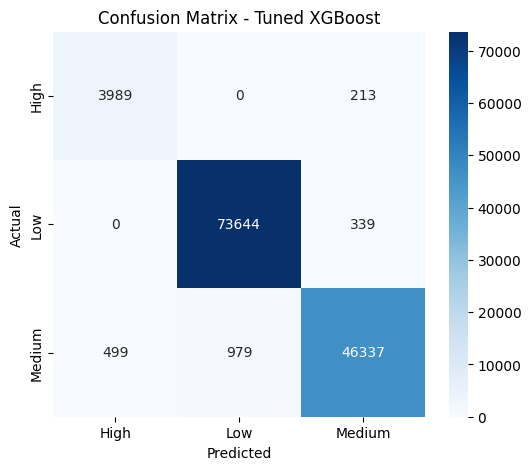

In [74]:
cm = confusion_matrix(y_test_encoded, y_pred_xgb)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_encoder.classes_,
    yticklabels=target_encoder.classes_
)

plt.title("Confusion Matrix - Tuned XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 10. Save Final Model and Encoder

In [77]:
joblib.dump(best_xgb_model, "best_xgboost_irrigation_pipeline.pkl")
joblib.dump(target_encoder, "target_encoder.pkl")

['target_encoder.pkl']

## 11. Sample Prediction

In [81]:
# ============================================================
# Sample Prediction Cell - Irrigation Need Prediction
# ============================================================

# 1. Import required libraries
import pandas as pd
import numpy as np
import joblib

# Import your feature engineering function
from feature_engineering import add_irrigation_features


# 2. Load saved model pipeline and target encoder
model = joblib.load("best_xgboost_irrigation_pipeline.pkl")
target_encoder = joblib.load("target_encoder.pkl")


# 3. Create raw input sample
# User/dashboard should enter only these raw features
sample_input = {
    "Soil_Type": "Loamy",
    "Soil_pH": 6.8,
    "Soil_Moisture": 28.5,
    "Organic_Carbon": 0.9,
    "Electrical_Conductivity": 1.4,
    "Temperature_C": 34.0,
    "Humidity": 45.0,
    "Rainfall_mm": 700.0,
    "Sunlight_Hours": 8.5,
    "Wind_Speed_kmh": 12.0,
    "Crop_Type": "Rice",
    "Crop_Growth_Stage": "Flowering",
    "Season": "Zaid",
    "Irrigation_Type": "Drip",
    "Water_Source": "River",
    "Field_Area_hectare": 4.5,
    "Mulching_Used": "No",
    "Previous_Irrigation_mm": 30.0,
    "Region": "South"
}


# 4. Convert input dictionary to DataFrame
input_df = pd.DataFrame([sample_input])

print("Raw Input:")
display(input_df)


# 5. Apply same feature engineering used during training
input_fe = add_irrigation_features(input_df)

# Drop id if present, because it was not used during training
if "id" in input_fe.columns:
    input_fe = input_fe.drop("id", axis=1)

print("Input After Feature Engineering:")
display(input_fe.head())


# 6. Make prediction
pred_encoded = model.predict(input_fe)[0]

# Convert encoded prediction back to original label
pred_label = target_encoder.inverse_transform([int(pred_encoded)])[0]


# 7. Get prediction probabilities / confidence
pred_proba = model.predict_proba(input_fe)[0]

confidence = pred_proba.max()

proba_df = pd.DataFrame({
    "Irrigation_Need": target_encoder.classes_,
    "Probability": pred_proba
}).sort_values(by="Probability", ascending=False)


# 8. Display final result
print("=" * 50)
print("Prediction Result")
print("=" * 50)

print("Predicted Irrigation Need:", pred_label)
print("Confidence:", round(confidence * 100, 2), "%")

print("\nClass-wise Probabilities:")
display(proba_df)

Raw Input:


,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region
0,Loamy,6.8,28.5,0.9,1.4,34.0,45.0,700.0,8.5,12.0,Rice,Flowering,Zaid,Drip,River,4.5,No,30.0,South


Input After Feature Engineering:


,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,total_water_input,rainfall_minus_prev_irr,prev_irr_minus_rainfall,water_input_per_hectare,rainfall_per_hectare,prev_irr_per_hectare,moisture_deficit,moisture_humidity_ratio,rainfall_moisture_ratio,prev_irr_moisture_ratio,water_input_moisture_ratio,field_moisture_reserve,temp_humidity_index,temperature_sunlight,sunlight_wind,wind_humidity_interaction,evapotranspiration_proxy,evaporation_pressure,dryness_index,rain_per_sunshine,temp_rainfall_ratio,sunlight_rainfall_ratio,rainfall_humidity_interaction,ec_ph_interaction,carbon_moisture,carbon_ph_interaction,salinity_moisture_stress,soil_health_index,ph_deviation_from_neutral,net_water_need,water_balance_index,water_stress_index,field_rainfall,field_previous_irrigation,field_water_input,field_evaporation_pressure
0,Loamy,6.8,28.5,0.9,1.4,34.0,45.0,700.0,8.5,12.0,Rice,Flowering,Zaid,Drip,River,4.5,No,30.0,South,730.0,670.0,-670.0,162.222186,155.555521,6.666665,71.5,0.633333,24.561403,1.052632,25.614034,128.25,15.3,289.0,102.0,540.0,10.275555,20.675,0.014076,82.352931,0.048571,0.012143,31500.0,9.52,25.65,6.12,0.049123,18.321415,0.2,74.475555,648.224445,1.006441,3150.0,135.0,3285.0,93.0375


Prediction Result
Predicted Irrigation Need: Medium
Confidence: 99.38 %

Class-wise Probabilities:


,Irrigation_Need,Probability
2,Medium,0.993797
0,High,0.005929
1,Low,0.000274
